In [50]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [26]:
data = load_breast_cancer()
type(data)
data.keys()


dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [25]:
data.data.shape

(569, 30)

In [31]:
data.target_names
#data.feature_names

array(['malignant', 'benign'], dtype='<U9')

In [35]:
X_train, X_test, y_train, y_test = train_test_split(data.data, data.target, test_size=0.33)

In [41]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [45]:
D = X_train.shape[1]
model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(D,)),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

In [47]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [48]:
r = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=100)

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.7927 - loss: 0.5695 - val_accuracy: 0.7181 - val_loss: 0.5831
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8268 - loss: 0.5185 - val_accuracy: 0.7713 - val_loss: 0.5418
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8425 - loss: 0.4759 - val_accuracy: 0.7979 - val_loss: 0.5058
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8688 - loss: 0.4407 - val_accuracy: 0.8191 - val_loss: 0.4745
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8766 - loss: 0.4104 - val_accuracy: 0.8351 - val_loss: 0.4478
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8871 - loss: 0.3853 - val_accuracy: 0.8564 - val_loss: 0.4243
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8924 - loss: 0.3635 - val_accuracy: 0.8670 - val_loss: 0.4037
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9003 - loss: 0.3450 - val_accuracy: 0.867

In [49]:
print("Train score:", model.evaluate(X_train, y_train))
print("Test score:", model.evaluate(X_test, y_test))

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9764 - loss: 0.0905 
Train score: [0.09051300585269928, 0.9763779640197754]
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9734 - loss: 0.0957
Test score: [0.09571154415607452, 0.9734042286872864]


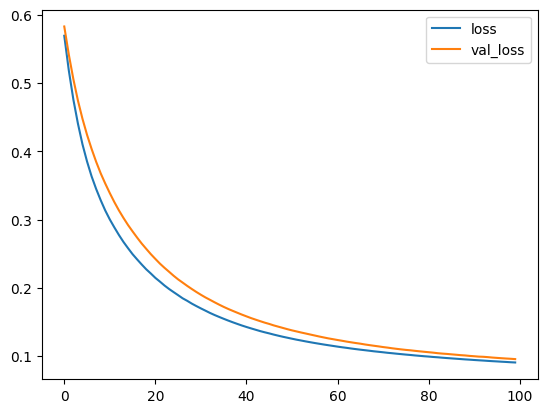

In [51]:
plt.plot(r.history['loss'], label='loss')
plt.plot(r.history['val_loss'], label='val_loss')
plt.legend()

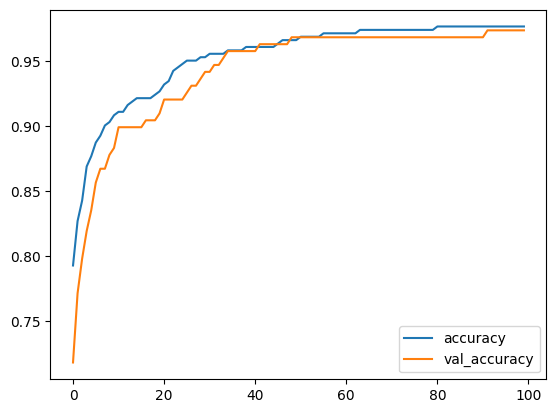

In [52]:
plt.plot(r.history['accuracy'], label='accuracy')
plt.plot(r.history['val_accuracy'], label='val_accuracy')
plt.legend()
#